In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
customers=pd.read_csv("olist_customers_dataset.csv")
geo=pd.read_csv("olist_geolocation_dataset.csv")
orders=pd.read_csv("olist_orders_dataset.csv")
order_items=pd.read_csv("olist_order_items_dataset.csv")
order_payments=pd.read_csv("olist_order_payments_dataset.csv")
order_reviews=pd.read_csv("olist_order_reviews_dataset.csv")
products=pd.read_csv("olist_products_dataset.csv")
sellers=pd.read_csv("olist_sellers_dataset.csv")

In [3]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [4]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [5]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [6]:
geo.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [7]:
geo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [8]:
geo.isnull().sum()

geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

In [9]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [10]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [11]:
orders["order_purchase_timestamp"]= pd.to_datetime(orders["order_purchase_timestamp"])
orders["order_approved_at"] = pd.to_datetime(orders["order_approved_at"])
orders["order_delivered_carrier_date"]= pd.to_datetime(orders["order_delivered_carrier_date"])
orders["order_delivered_customer_date"]= pd.to_datetime(orders["order_delivered_customer_date"])
orders["order_estimated_delivery_date"]= pd.to_datetime(orders["order_estimated_delivery_date"])

In [12]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [13]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [14]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [15]:
orders[orders['order_delivered_customer_date'].isnull()]['order_status'].value_counts()

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

# Here we don't fill the null value, because these null values are not created. These are business insights where the order is cancelled or unavailable , so these are those values. We cannot fill these values.
 <!-- if we analyze the data, then we filter the data and make a flags.  -->

In [16]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [17]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [18]:
order_items["shipping_limit_date"]=pd.to_datetime(order_items["shipping_limit_date"])

In [19]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


In [20]:
order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [21]:
order_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [22]:
order_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [23]:
order_payments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [24]:
order_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [25]:
order_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [26]:
order_reviews["review_creation_date"]=pd.to_datetime(order_reviews["review_creation_date"])
order_reviews["review_answer_timestamp"]=pd.to_datetime(order_reviews["review_answer_timestamp"])

In [27]:
order_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  int64         
 3   review_comment_title     11568 non-null  object        
 4   review_comment_message   40977 non-null  object        
 5   review_creation_date     99224 non-null  datetime64[ns]
 6   review_answer_timestamp  99224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 5.3+ MB


In [28]:
order_reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [29]:
order_reviews['review_comment_title'].fillna('No Title', inplace=True)
order_reviews['review_comment_message'].fillna('No Comment', inplace=True)

C:\Users\nitti\AppData\Local\Temp\ipykernel_24684\1545536221.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  order_reviews['review_comment_title'].fillna('No Title', inplace=True)
C:\Users\nitti\AppData\Local\Temp\ipykernel_24684\1545536221.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behav

In [30]:
order_reviews.isnull().sum()

review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
dtype: int64

In [31]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [32]:
products.rename(columns={
    "product_photos_qty":"photos_qty",
    "product_description_lenght":"description_length",
    "product_name_lenght":"name_length",
    "product_category_name":"category_name",
    'product_weight_g': 'weight_grams',
    'product_length_cm': 'length_cm',
    'product_height_cm': 'height_cm',
    'product_width_cm': 'width_cm'
}, inplace=True)

In [33]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   product_id          32951 non-null  object 
 1   category_name       32341 non-null  object 
 2   name_length         32341 non-null  float64
 3   description_length  32341 non-null  float64
 4   photos_qty          32341 non-null  float64
 5   weight_grams        32949 non-null  float64
 6   length_cm           32949 non-null  float64
 7   height_cm           32949 non-null  float64
 8   width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [34]:
products.isnull().sum()

product_id              0
category_name         610
name_length           610
description_length    610
photos_qty            610
weight_grams            2
length_cm               2
height_cm               2
width_cm                2
dtype: int64

In [35]:
products['name_length'].fillna(products['name_length'].median(), inplace=True)
products['description_length'].fillna(products['description_length'].median(), inplace=True)

C:\Users\nitti\AppData\Local\Temp\ipykernel_24684\1039547280.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products['name_length'].fillna(products['name_length'].median(), inplace=True)
C:\Users\nitti\AppData\Local\Temp\ipykernel_24684\1039547280.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alwa

In [36]:
products['photos_qty'].fillna(0, inplace=True)

C:\Users\nitti\AppData\Local\Temp\ipykernel_24684\3429475792.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products['photos_qty'].fillna(0, inplace=True)


In [37]:
products['weight_grams'].fillna(products['weight_grams'].median(), inplace=True)
products['length_cm'].fillna(products['length_cm'].median(), inplace=True)
products['height_cm'].fillna(products['height_cm'].median(), inplace=True)
products['width_cm'].fillna(products['width_cm'].median(), inplace=True)

C:\Users\nitti\AppData\Local\Temp\ipykernel_24684\2371166003.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products['weight_grams'].fillna(products['weight_grams'].median(), inplace=True)
C:\Users\nitti\AppData\Local\Temp\ipykernel_24684\2371166003.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values al

In [38]:
products.isnull().sum()

product_id              0
category_name         610
name_length             0
description_length      0
photos_qty              0
weight_grams            0
length_cm               0
height_cm               0
width_cm                0
dtype: int64

In [39]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [40]:
sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [41]:
sellers.isnull().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [42]:
geo.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [43]:
# her ewe merge the all files and make on dataset 

In [44]:
geo_clean = geo.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean'
}).reset_index()

In [45]:
customers = customers.merge(
    geo_clean,
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
)

In [46]:
df = orders.merge(customers, on='customer_id', how='left') \
           .merge(order_items, on='order_id', how='left') \
           .merge(order_payments, on='order_id', how='left') \
           .merge(order_reviews, on='order_id', how='left') \
           .merge(products, on='product_id', how='left') \
           .merge(sellers, on='seller_id', how='left')

In [47]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,name_length,description_length,photos_qty,weight_grams,length_cm,height_cm,width_cm,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,29.0,178.0,1.0,400.0,19.0,13.0,19.0,31570.0,belo horizonte,SP
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,46.0,232.0,1.0,420.0,24.0,19.0,21.0,14840.0,guariba,SP


In [48]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'geolocation_zip_code_prefix', 'geolocation_lat',
       'geolocation_lng', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value', 'payment_sequential',
       'payment_type', 'payment_installments', 'payment_value', 'review_id',
       'review_score', 'review_comment_title', 'review_comment_message',
       'review_creation_date', 'review_answer_timestamp', 'category_name',
       'name_length', 'description_length', 'photos_qty', 'weight_grams',
       'length_cm', 'height_cm', 'width_cm', 'seller_zip_code_prefix',
       'seller_city', 'seller_state'],
      dtype='object')

In [49]:
# df.to_csv('final_dataset.csv', index=False)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 42 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119143 non-null  object        
 1   customer_id                    119143 non-null  object        
 2   order_status                   119143 non-null  object        
 3   order_purchase_timestamp       119143 non-null  datetime64[ns]
 4   order_approved_at              118966 non-null  datetime64[ns]
 5   order_delivered_carrier_date   117057 non-null  datetime64[ns]
 6   order_delivered_customer_date  115722 non-null  datetime64[ns]
 7   order_estimated_delivery_date  119143 non-null  datetime64[ns]
 8   customer_unique_id             119143 non-null  object        
 9   customer_zip_code_prefix       119143 non-null  int64         
 10  customer_city                  119143 non-null  object        
 11  

In [51]:
df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 177
order_delivered_carrier_date     2086
order_delivered_customer_date    3421
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
geolocation_zip_code_prefix       322
geolocation_lat                   322
geolocation_lng                   322
order_item_id                     833
product_id                        833
seller_id                         833
shipping_limit_date               833
price                             833
freight_value                     833
payment_sequential                  3
payment_type                        3
payment_installments                3
payment_value                       3
review_id                         997
review_score

In [52]:
# Drop broken order rows
df.dropna(subset=['product_id', 'price'], inplace=True)



In [53]:
# Fill the geo loaction 
df['geolocation_lat'].fillna(df['geolocation_lat'].median(), inplace=True)
df['geolocation_lng'].fillna(df['geolocation_lng'].median(), inplace=True)


C:\Users\nitti\AppData\Local\Temp\ipykernel_24684\2221608703.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['geolocation_lat'].fillna(df['geolocation_lat'].median(), inplace=True)
C:\Users\nitti\AppData\Local\Temp\ipykernel_24684\2221608703.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always b

In [54]:
# Payment
df['payment_type'].fillna('Unknown', inplace=True)
df['payment_value'].fillna(df['payment_value'].median(), inplace=True)
df['payment_sequential'].fillna(1, inplace=True)
df['payment_installments'].fillna(df['payment_installments'].median(), inplace=True)


C:\Users\nitti\AppData\Local\Temp\ipykernel_24684\314128181.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['payment_type'].fillna('Unknown', inplace=True)
C:\Users\nitti\AppData\Local\Temp\ipykernel_24684\314128181.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [55]:
# Reviews
df['review_comment_message'].fillna('No Comment', inplace=True)
df['review_comment_title'].fillna('No Title', inplace=True)



C:\Users\nitti\AppData\Local\Temp\ipykernel_24684\3963882199.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['review_comment_message'].fillna('No Comment', inplace=True)
C:\Users\nitti\AppData\Local\Temp\ipykernel_24684\3963882199.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a

In [56]:
# Product
df['category_name'].fillna('Unknown', inplace=True)
df['name_length'].fillna(df['name_length'].median(), inplace=True)
df['description_length'].fillna(df['description_length'].median(), inplace=True)
df['photos_qty'].fillna(0, inplace=True)


C:\Users\nitti\AppData\Local\Temp\ipykernel_24684\3655924170.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['category_name'].fillna('Unknown', inplace=True)
C:\Users\nitti\AppData\Local\Temp\ipykernel_24684\3655924170.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

In [57]:
# product details
df['weight_grams'].fillna(df['weight_grams'].median(), inplace=True)
df['length_cm'].fillna(df['length_cm'].median(), inplace=True)
df['height_cm'].fillna(df['height_cm'].median(), inplace=True)
df['width_cm'].fillna(df['width_cm'].median(), inplace=True)

C:\Users\nitti\AppData\Local\Temp\ipykernel_24684\1816651873.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['weight_grams'].fillna(df['weight_grams'].median(), inplace=True)
C:\Users\nitti\AppData\Local\Temp\ipykernel_24684\1816651873.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves

In [58]:
df['has_review'] = df['review_score'].notnull()

In [59]:
df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1254
order_delivered_customer_date    2588
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
geolocation_zip_code_prefix       317
geolocation_lat                     0
geolocation_lng                     0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
payment_sequential                  0
payment_type                        0
payment_installments                0
payment_value                       0
review_id                         978
review_score

In [60]:
# Drop zipcode because we have geo loaction 
df.drop("geolocation_zip_code_prefix",axis=1,inplace=True)

In [61]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,description_length,photos_qty,weight_grams,length_cm,height_cm,width_cm,seller_zip_code_prefix,seller_city,seller_state,has_review
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,True
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,True
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,True
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,178.0,1.0,400.0,19.0,13.0,19.0,31570.0,belo horizonte,SP,True
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,232.0,1.0,420.0,24.0,19.0,21.0,14840.0,guariba,SP,True


In [62]:
# we check duplicate values 
df.duplicated().sum()

np.int64(0)

In [63]:
df["order_purchase_timestamp"].head()

0   2017-10-02 10:56:33
1   2017-10-02 10:56:33
2   2017-10-02 10:56:33
3   2018-07-24 20:41:37
4   2018-08-08 08:38:49
Name: order_purchase_timestamp, dtype: datetime64[ns]

In [64]:
# Order value
df['order_value'] = df['price'] + df['freight_value']

# Delivery time
df['delivery_time'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days

# we extract date month and year from order_purchase_timestamp 
df["order_date"]=df["order_purchase_timestamp"].dt.day
df["order_day_name"]=df["order_purchase_timestamp"].dt.day_name()
df["order_month"]=df["order_purchase_timestamp"].dt.month
df["order_month_name"]=df["order_purchase_timestamp"].dt.month_name()
df["order_year"]=df["order_purchase_timestamp"].dt.year



In [65]:
# we sort the month name like january,feb,march,april.....
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

df['order_month_name'] = pd.Categorical(
    df['order_month_name'],
    categories=month_order,
    ordered=True
)

# Revenue Trend by Month

C:\Users\nitti\AppData\Local\Temp\ipykernel_24684\727039015.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_revenue = df.groupby('order_month_name')['order_value'].sum()


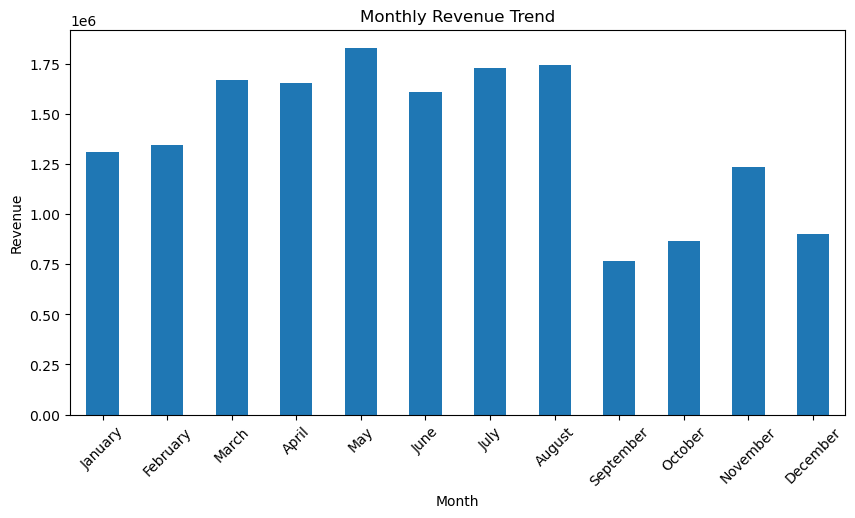

In [66]:
monthly_revenue = df.groupby('order_month_name')['order_value'].sum()
monthly_revenue.plot(kind="bar",figsize=(10,5))
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

In [67]:
# Most Revenue  came in a "May" month and lees Revenue in a  "September" month 

# Revenue Trend by Year

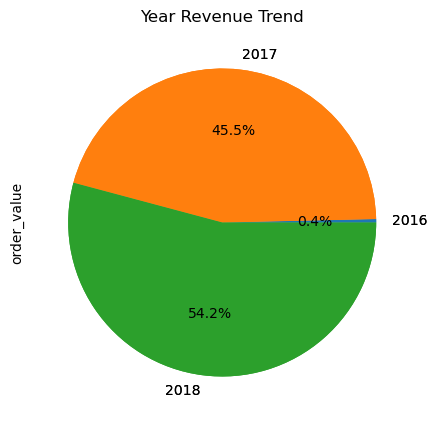

In [118]:
year_revenue = df.groupby('order_year')['order_value'].sum()
year_revenue.plot(kind="pie",figsize=(10,5))
plt.pie(year_revenue, labels=year_revenue.index, autopct='%1.1f%%')
plt.title('Year Revenue Trend')
plt.show()

# Revenue Trend by Weekdays

In [69]:
# sort the order days 
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

df['order_day_name'] = pd.Categorical(
    df['order_day_name'],
    categories=day_order,
    ordered=True
)

C:\Users\nitti\AppData\Local\Temp\ipykernel_24684\2194346213.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Weekdays_revenue = df.groupby('order_day_name')['order_value'].sum()


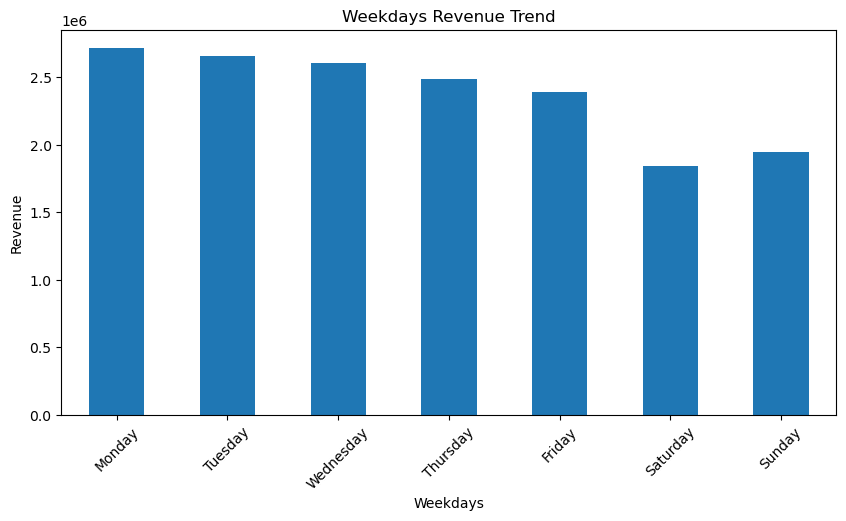

In [70]:
Weekdays_revenue = df.groupby('order_day_name')['order_value'].sum()
Weekdays_revenue.plot(kind="bar",figsize=(10,5))
plt.title('Weekdays Revenue Trend')
plt.xlabel('Weekdays')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

# Orders Trend Month Wise 

C:\Users\nitti\AppData\Local\Temp\ipykernel_24684\833177469.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  orders_count = df.groupby('order_month_name')['order_id'].count()


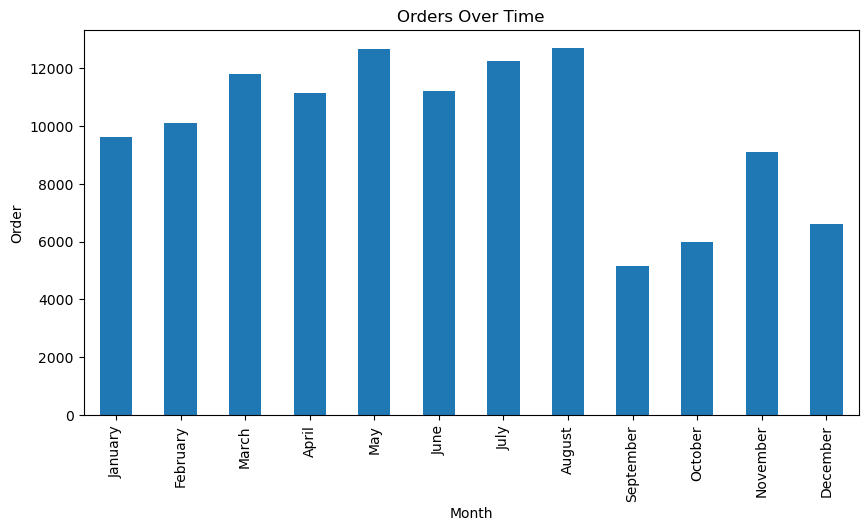

In [71]:
orders_count = df.groupby('order_month_name')['order_id'].count()
orders_count.plot( kind="bar",figsize=(10,5))
plt.title('Orders Over Time')
plt.xlabel('Month')
plt.ylabel('Order')

plt.show()

In [72]:
# Highest order in a "May" and "Agust" .
# Lowerst order in "September"

# Orders Trend Year Wise

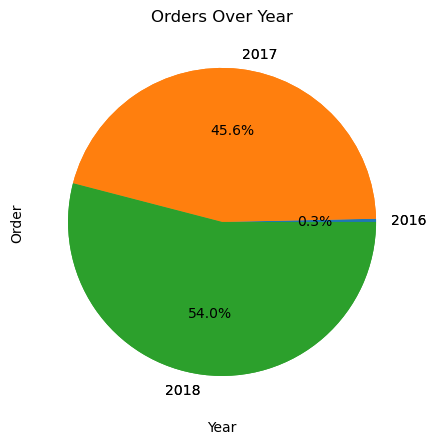

In [117]:
orders_count = df.groupby('order_year')['order_id'].count()
orders_count.plot( kind="pie",figsize=(10,5))
plt.pie(orders_count, labels=orders_count.index, autopct='%1.1f%%')
plt.title('Orders Over Year')
plt.xlabel('Year')
plt.ylabel('Order')
plt.show()

C:\Users\nitti\AppData\Local\Temp\ipykernel_24684\663253520.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  orders_count = df.groupby('order_day_name')['order_id'].count()


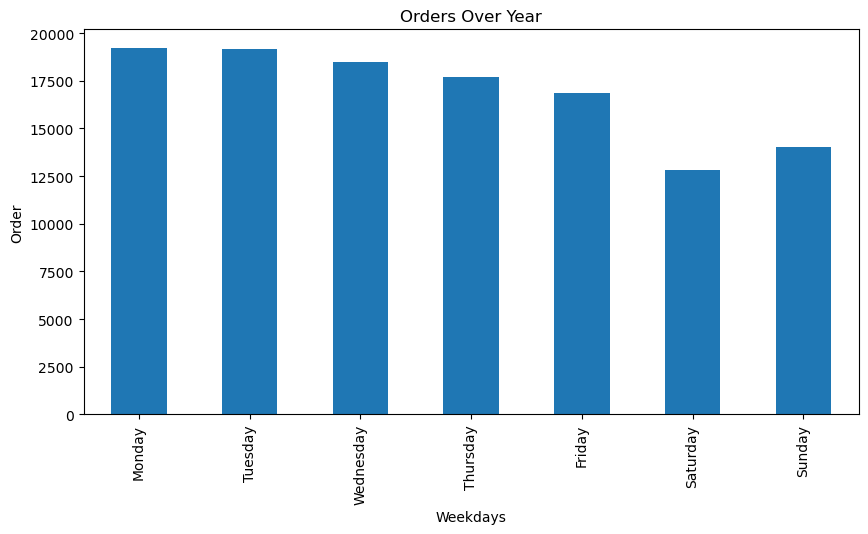

In [74]:
orders_count = df.groupby('order_day_name')['order_id'].count()
orders_count.plot( kind="bar",figsize=(10,5))
plt.title('Orders Over Year')
plt.xlabel('Weekdays')
plt.ylabel('Order')
plt.show()

# Average Order Per Month 

C:\Users\nitti\AppData\Local\Temp\ipykernel_24684\3279019897.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_order = df.groupby('order_month_name')['order_value'].mean()


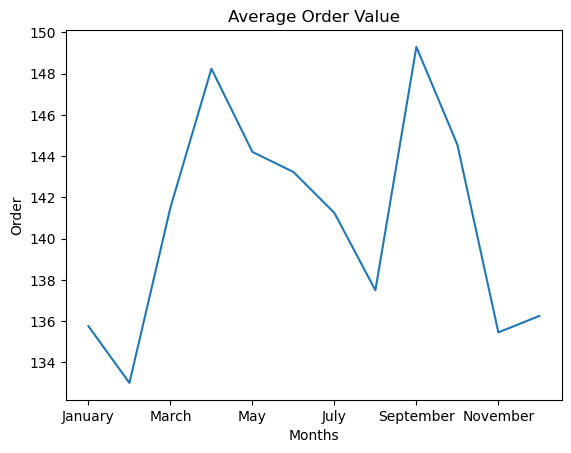

In [75]:
avg_order = df.groupby('order_month_name')['order_value'].mean()
avg_order.plot()
plt.title('Average Order Value')
plt.xlabel("Months")
plt.ylabel("Order")
plt.show()

# Average Order Per Day

C:\Users\nitti\AppData\Local\Temp\ipykernel_24684\4231823699.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_order = df.groupby('order_day_name')['order_value'].mean()


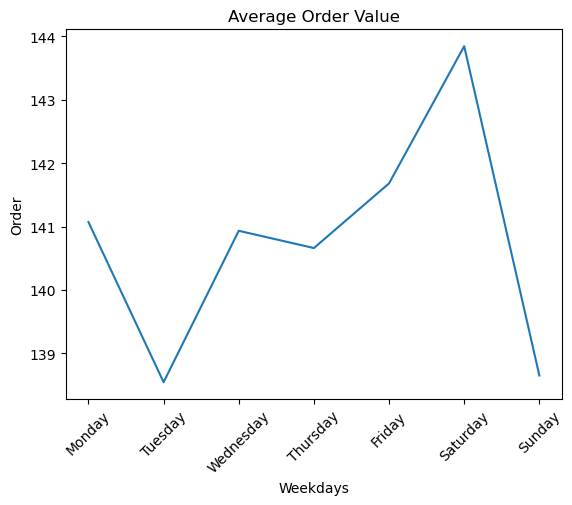

In [76]:
avg_order = df.groupby('order_day_name')['order_value'].mean()
avg_order.plot()
plt.title('Average Order Value')
plt.xlabel("Weekdays")
plt.ylabel("Order")
plt.xticks(rotation=45)
plt.show()

# Top Categories

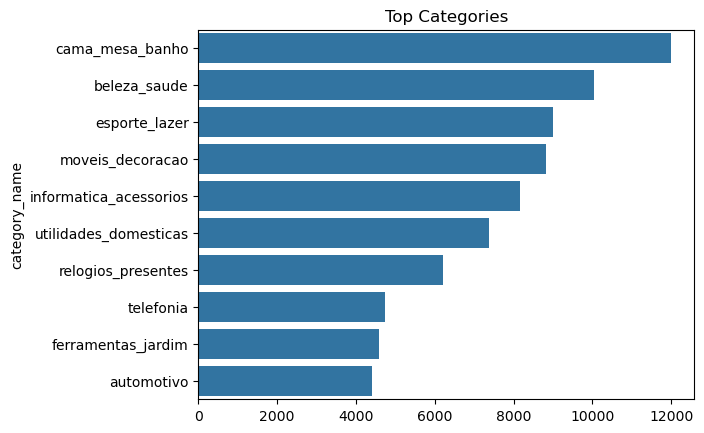

In [77]:
top_cat = df['category_name'].value_counts().head(10)

sns.barplot(x=top_cat.values, y=top_cat.index)
plt.title('Top Categories')
plt.show()

# Top Cities

# Top Cities by Revenue

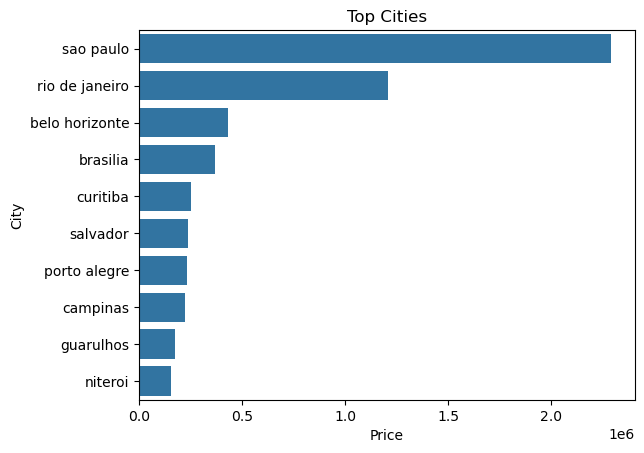

In [78]:
top_cities = df.groupby('customer_city')['order_value'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_cities.values, y=top_cities.index)
plt.title('Top Cities')
plt.xlabel("Price")
plt.ylabel("City")
plt.show()

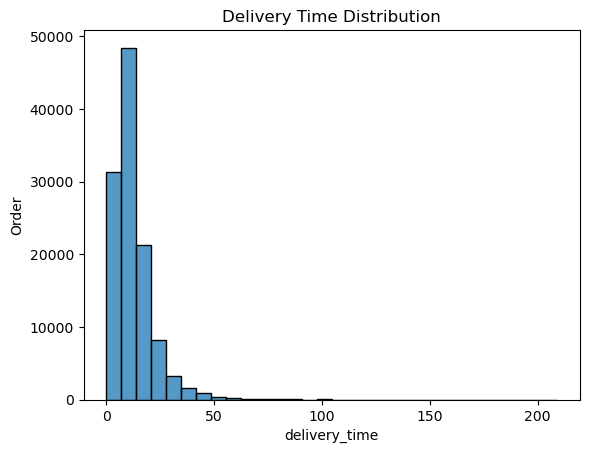

In [79]:
sns.histplot(df['delivery_time'], bins=30)
plt.title('Delivery Time Distribution')
plt.ylabel("Order")
plt.show()

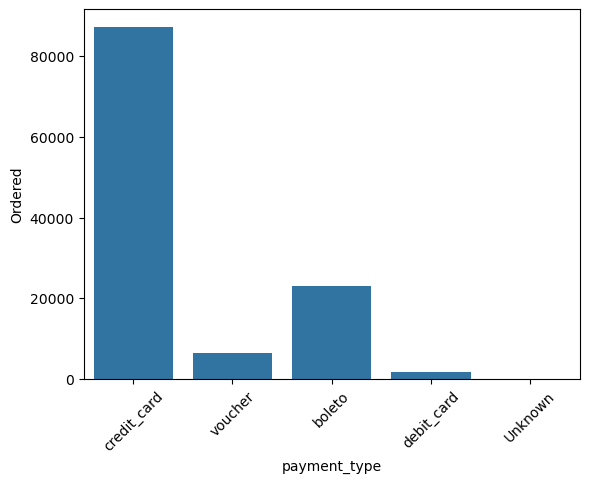

In [80]:
sns.countplot(x='payment_type', data=df)
plt.xticks(rotation=45)
plt.ylabel("Ordered")
plt.show()

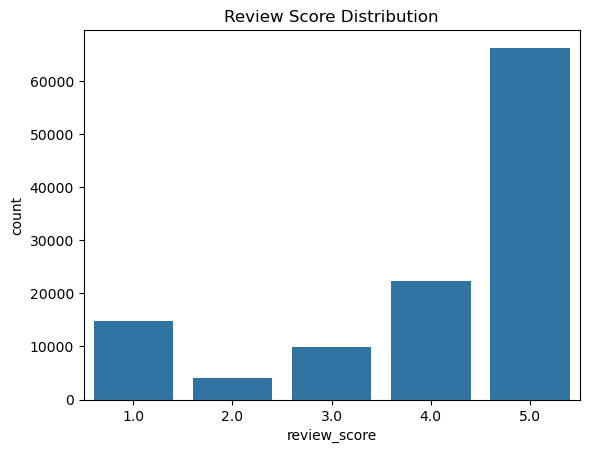

In [81]:
sns.countplot(x='review_score', data=df)
plt.title('Review Score Distribution')
plt.show()

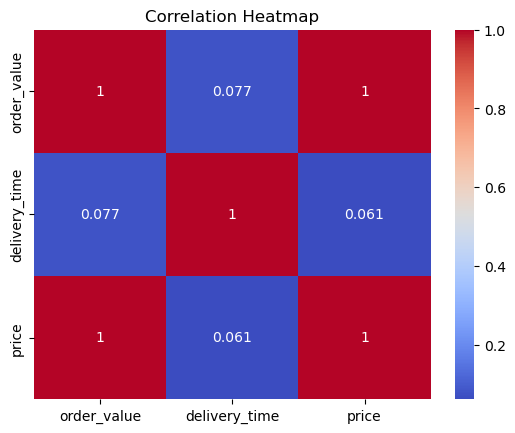

In [82]:
corr = df[['order_value','delivery_time','price']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [83]:
rfm = df.groupby('customer_id').agg({
    'order_purchase_timestamp': 'max',
    'order_id': 'count',
    'order_value': 'sum'
}).reset_index()

rfm.columns = ['customer_id', 'last_purchase', 'frequency', 'monetary']

rfm['recency'] = (df['order_purchase_timestamp'].max() - rfm['last_purchase']).dt.days

In [84]:
rfm.head()

,customer_id,last_purchase,frequency,monetary,recency
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,1,114.74,292
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,1,67.41,413
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,1,195.42,551
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,1,179.35,382
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,1,107.01,153


In [109]:
rfm['R_score'] = pd.qcut(rfm['recency'], 4, duplicates='drop')
rfm['F_score'] = pd.qcut(rfm['frequency'], 4, duplicates='drop')
rfm['M_score'] = pd.qcut(rfm['monetary'], 4, duplicates='drop')

# Convert to numeric scores
rfm['R_score'] = rfm['R_score'].cat.codes + 1
rfm['F_score'] = rfm['F_score'].cat.codes + 1
rfm['M_score'] = rfm['M_score'].cat.codes + 1

In [110]:
rfm['RFM_score'] = rfm['R_score'].astype(str) + \
                   rfm['F_score'].astype(str) + \
                   rfm['M_score'].astype(str)

In [111]:
def segment_customer(row):
    if row['R_score']==4 and row['F_score']==4 and row['M_score']==4:
        return 'VIP'
    elif row['F_score']>=3 and row['M_score']>=3:
        return 'Loyal'
    elif row['R_score']<=2:
        return 'At Risk'
    else:
        return 'Regular'

rfm['segment'] = rfm.apply(segment_customer, axis=1)

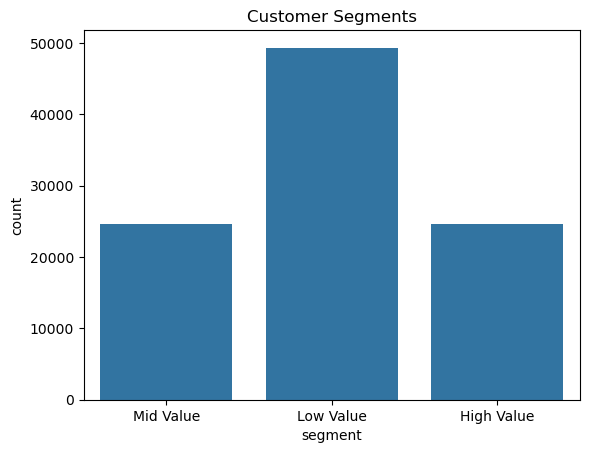

In [107]:
sns.countplot(x='segment', data=rfm)
plt.title('Customer Segments')
plt.show()